In [1]:
import numpy as np
from matplotlib import pyplot as plt
from echospec.utils.parameters import Parameters
from echospec.experiments.spectroscopy_vs_amplitude import AmplitudeSweepSpectroscopy, OptionsSpectroscopy2d
from echospec.utils.units import Units as u

Amplitude sweep:   0%|          | 0/2 [00:00<?, ?Ω/s]

Amplitude sweep:   0%|          | 0/2 [00:00<?, ?Ω/s]

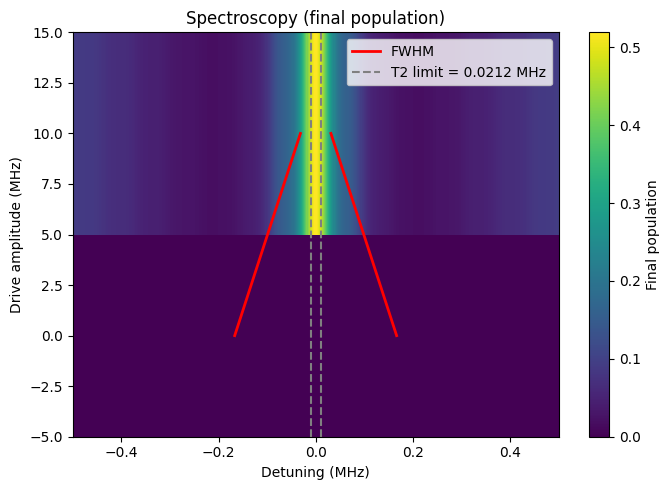

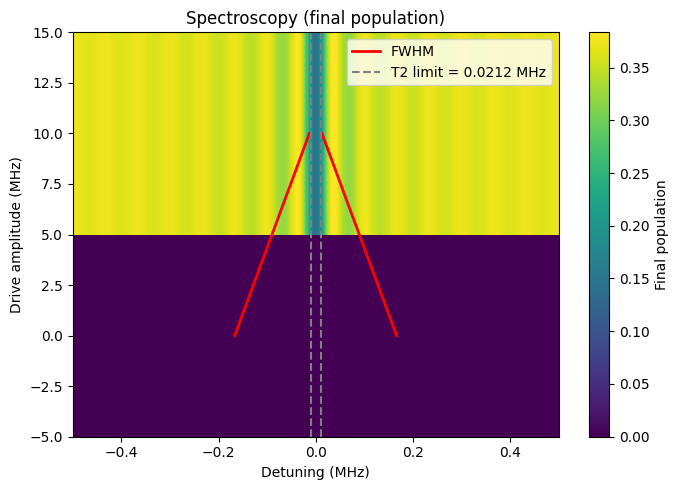

In [2]:
options = OptionsSpectroscopy2d(plot=True)
options.num_time_points = 3000

detunings = np.linspace(-0.5, 0.5, 451) * 2 * np.pi * u.MHz
amplitudes = np.linspace(0, 10, 2) * 2 * np.pi * u.MHz

results = {}

params = Parameters()
params.cutoff = 7e-4
params.pulse_length = 30 * u.us


for echo_on in (False, True):
    params.eco_pulse = echo_on

    spec = AmplitudeSweepSpectroscopy(
        amplitudes=amplitudes,
        detunings=detunings,
        params=params,
        options=options
    )
    results[echo_on] = spec.run()

# optional named aliases
results_no_echo = results[False]
results_echo = results[True]










In [3]:
# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

MHz = 1e6


def z_to_population(z):
    """Map Bloch-Z → excited-state population."""
    return 0.5 * (1 - z)


def detuning_to_mhz(det):
    return det / MHz


def extract_z(data, amp_idx):
    """Extract Z component for selected amplitude."""
    return data[:, 2, :, :][amp_idx]



/var/folders/5l/mx_yndbx4sq978lx9ht2346r0000gn/T/ipykernel_69321/3863686276.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])


FileNotFoundError: [Errno 2] No such file or directory: 'lorentzian_pulse_transparent.png'

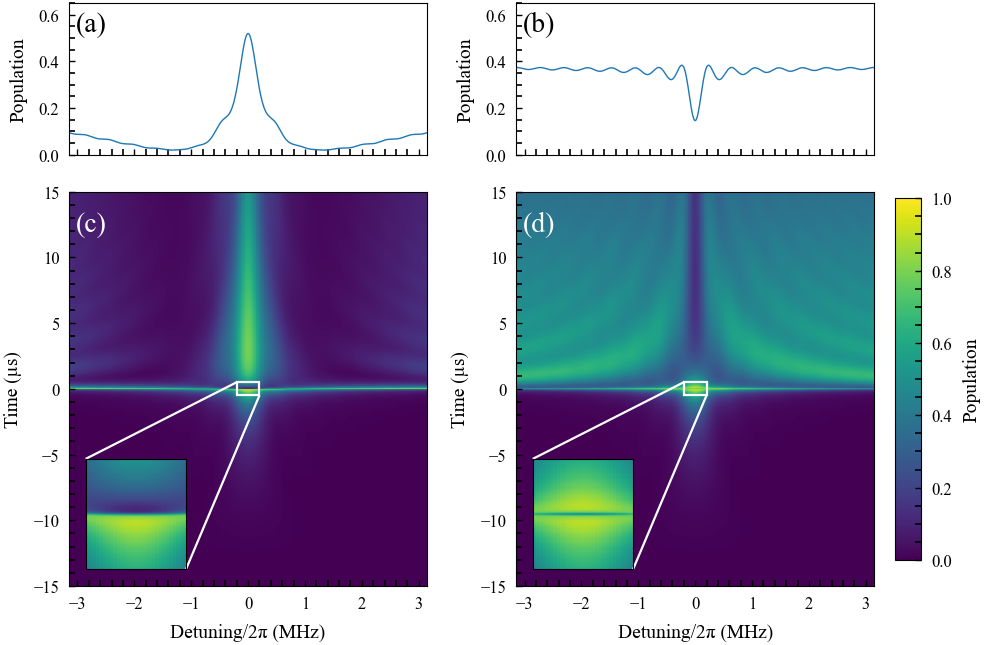

In [4]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from echospec.figures import FigureVariant, apply_figure_style, save_figure

VARIANT = FigureVariant.PAPER
apply_figure_style(VARIANT)

raw_data_1 = results[False].raw_data()
raw_data_2 = results[True].raw_data()
data = [raw_data_1, raw_data_2]

fig, axs = plt.subplots(
    2, 2,
    figsize=(5.2, 3.4),
    gridspec_kw={"height_ratios": [1, 2.6]},
    sharex=True,
)

# Zoom window for inset
detuning_zoom = (-0.2, 0.2)   # MHz
time_zoom = (-0.5, 0.5)       # µs

for i, raw_data in enumerate(data):
    z_data = extract_z(raw_data, -1)
    population_data = z_to_population(z_data)

    time_us = np.asarray(globals().get(
        "ts_us", np.linspace(-15.0, 15.0, population_data.shape[1])
    ))
    detuning_mhz = detuning_to_mhz(detunings)

    # -----------------------
    # Top row: 1D spectrum
    # -----------------------
    spec_1d = population_data[:, -1]

    axs[0, i].plot(detuning_mhz, spec_1d)
    # axs[0, i].set_xlabel("Detuning/2π (MHz)")
    axs[0, i].set_ylabel("Population")
    axs[0, i].set_ylim(0, 0.65)

    # -----------------------
    # Bottom row: 2D map
    # x = detuning, y = time
    # -----------------------
    im = axs[1, i].pcolormesh(
        detuning_mhz,
        time_us,
        population_data.T,
        shading="auto",
        cmap="viridis",
        vmin=0,
        vmax=1,
    )

    axs[1, i].set_xlabel("Detuning/2π (MHz)")
    axs[1, i].set_ylabel("Time (µs)")

    # -----------------------
    # Inset zoom
    # x = detuning, y = time
    # -----------------------
    axins = inset_axes(
        axs[1, i],
        width="28%",
        height="28%",
        loc="lower left",
        borderpad=1,
    )

    axins.pcolormesh(
        detuning_mhz,
        time_us,
        population_data.T,
        shading="auto",
        cmap="viridis",
        vmin=0,
        vmax=1,
    )

    axins.set_xlim(*detuning_zoom)
    axins.set_ylim(*time_zoom)
    axins.set_xticks([])
    axins.set_yticks([])

    mark_inset(
        axs[1, i],
        axins,
        loc1=2,
        loc2=4,
        fc="none",
        ec="white",
        lw=0.8,
    )

# Panel labels
labels = ["(a)", "(b)", "(c)", "(d)"]

for ax, label in zip(axs.ravel(), labels):
    ax.text(
        0.02,
        0.95,
        label,
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        color="white" if ax in axs[1, :] else "black",
    )

# Arrange plots while leaving space for colorbar
fig.tight_layout(rect=[0, 0, 0.88, 1])

# Fixed colorbar axis
cbar_ax = fig.add_axes([0.88, 0.15, 0.025, 0.532])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Population")

# Add pulse images on bottom-row plots
image_files = [
    "lorentzian_pulse_transparent.png",
    "lorentzian_flip_pulse_transparent.png",
]

for col, fname in enumerate(image_files):
    img = mpimg.imread(fname)
    imagebox = OffsetImage(img, zoom=0.3)

    ab = AnnotationBbox(
        imagebox,
        (0.22, 0.75),
        xycoords="axes fraction",
        frameon=False,
    )

    axs[1, col].add_artist(ab)

save_figure(plt.gcf(), "2d_spectroscopy_simulation", variant=VARIANT, formats=("png",))
plt.show()